This program simulates a simple reflex agent in a vacuum environment with:
- Two rooms (A and B) that can be clean or dirty.
- An agent that cleans dirty rooms and moves between rooms.
- Performance measurement including cleaning and clean states.

In [1]:
pip install pygame

Defaulting to user installation because normal site-packages is not writeable
  Obtaining dependency information for pygame from https://files.pythonhosted.org/packages/d2/55/ca3eb851aeef4f6f2e98a360c201f0d00bd1ba2eb98e2c7850d80aabc526/pygame-2.6.1-cp311-cp311-win_amd64.whl.metadata
   ---------------------------------------- 0.0/10.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/10.6 MB 991.0 kB/s eta 0:00:11
   - -------------------------------------- 0.4/10.6 MB 5.1 MB/s eta 0:00:02
   --- ------------------------------------ 0.8/10.6 MB 6.6 MB/s eta 0:00:02
   ----- ---------------------------------- 1.3/10.6 MB 7.7 MB/s eta 0:00:02
   ------ --------------------------------- 1.8/10.6 MB 8.1 MB/s eta 0:00:02
   -------- ------------------------------- 2.2/10.6 MB 8.8 MB/s eta 0:00:01
   ---------- ----------------------------- 2.7/10.6 MB 8.6 MB/s eta 0:00:01
   ------------ --------------------------- 3.2/10.6 MB 8.9 MB/s eta 0:00:01
   -------------- ----------

In [2]:
pip install random

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement random (from versions: none)
ERROR: No matching distribution found for random


## Simple Reflection Proxy Implementation of Vacuum World


Initial State: {'A': 'Dirty', 'B': 'Dirty'}, Initial Location: A
Step 1: Action=Suck, Location=A, States={'A': 'Clean', 'B': 'Dirty'}, Performance Score=2, Energy Usage=1
Step 2: Action=Right, Location=B, States={'A': 'Clean', 'B': 'Dirty'}, Performance Score=3, Energy Usage=2
Step 3: Action=Suck, Location=B, States={'A': 'Clean', 'B': 'Clean'}, Performance Score=6, Energy Usage=3
Step 4: Action=Left, Location=A, States={'A': 'Clean', 'B': 'Clean'}, Performance Score=8, Energy Usage=4

Initial State: {'A': 'Clean', 'B': 'Dirty'}, Initial Location: A
Step 1: Action=Right, Location=B, States={'A': 'Clean', 'B': 'Dirty'}, Performance Score=1, Energy Usage=1
Step 2: Action=Suck, Location=B, States={'A': 'Clean', 'B': 'Clean'}, Performance Score=4, Energy Usage=2
Step 3: Action=Left, Location=A, States={'A': 'Clean', 'B': 'Clean'}, Performance Score=6, Energy Usage=3
Step 4: Action=Right, Location=B, States={'A': 'Clean', 'B': 'Clean'}, Performance Score=8, Energy Usage=4

Initial State: {

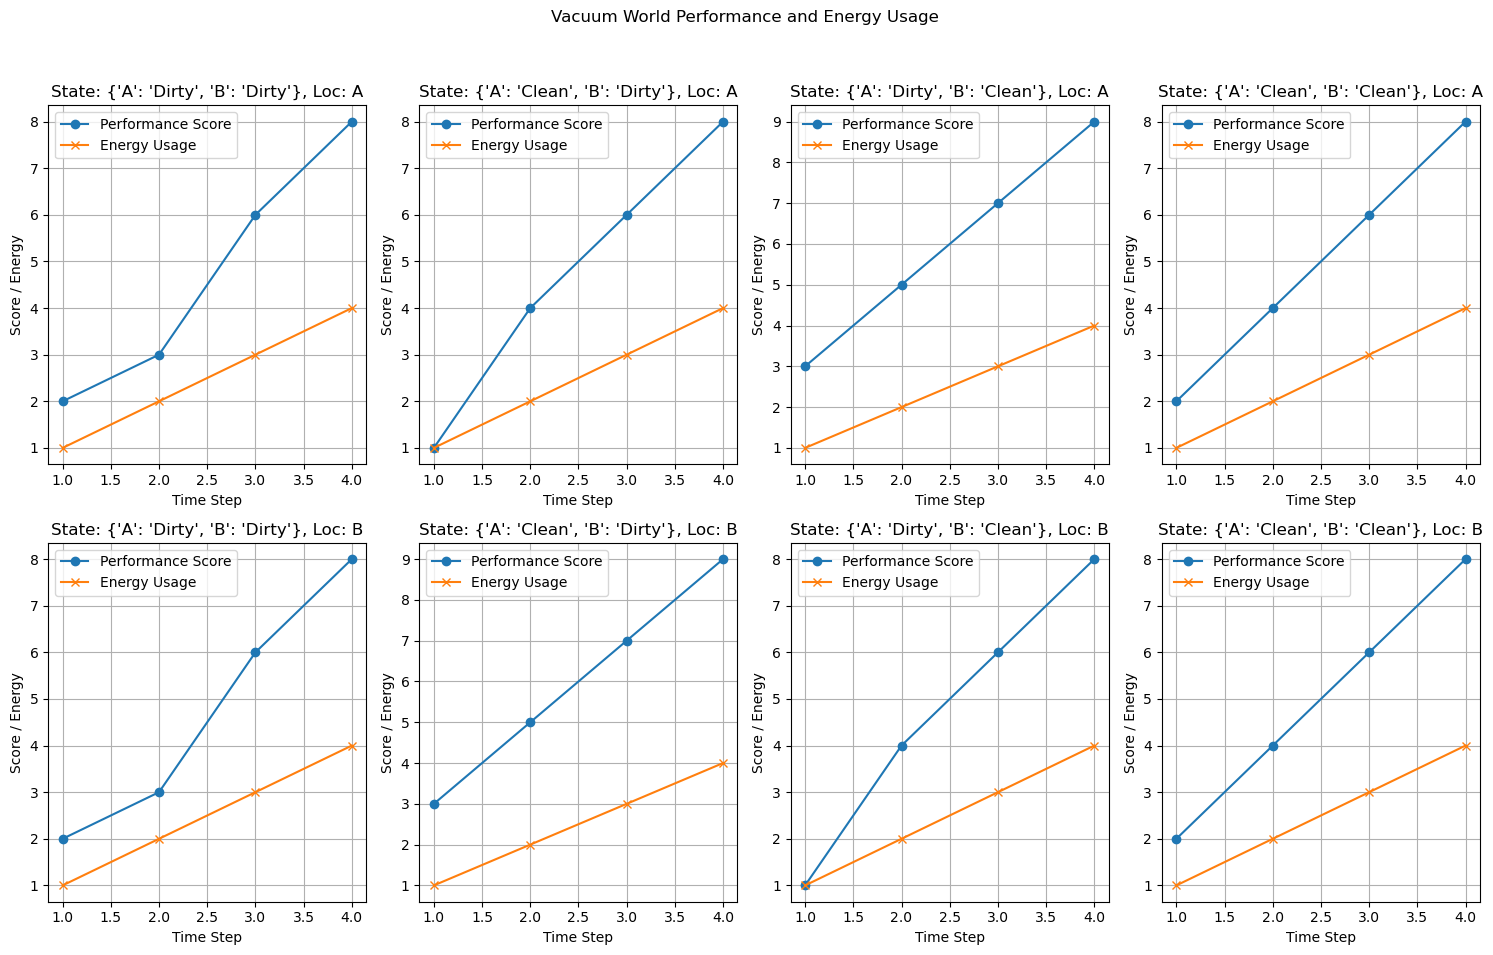

In [1]:
# Simple Reflection Proxy Implementation of Vacuum World
# Author: Xinyang Zhang
# Date: January,22 2025

import matplotlib.pyplot as plt

# setting environment 
# To make the code cleaner and neater, I use Objective in the Python programming language. 
# Totally there are three objects in this condition
# 1. environment
# 2. actuator
# 3. SimpleReflexAgent
class VacuumWorld:
    def __init__(self, initial_location="A"):
        # Initialize the state of the environment, the dirty or clean state of the A and B locations.
        # It is just a default setting, I will set complete configuration states in the main function
        self.states = {
            "A": "Dirty",  
            "B": "Dirty"   
        }
        
        # Initial position of the vacuum cleaner, can be set to A or B
        self.agent_location = initial_location  
        self.performance_score = 0  # Performance scores
        self.energy_usage = 0  # Energy Consumption Score
    
    # Sensor,this part I put into environment, because 
    def is_dirty(self):
        # Determine if the current vacuum cleaner location is dirty
        return self.states[self.agent_location] == "Dirty"

    
# Actuator action
# In order to make the code neater, I implemented the executor as a separate object
# I set 2 kinds of performance scores:
#    1.Add 1 performance score for each cleanup
#    2.Clearing actions and moving actions consume energy, adding energy usage scores.    
class Actuator:
    def __init__(self, environment):
        self.environment = environment

    def clean(self):
        # Clear current position
        self.environment.states[self.environment.agent_location] = "Clean"
        self.environment.performance_score += 1  # Add 1 point for each cleanup
        self.environment.energy_usage += 1  # Clearing movements burn energy

    def move_left(self):
        # The vacuum cleaner moves left to A
        self.environment.agent_location = "A"
        self.environment.energy_usage += 1  # Movements consume energy

    def move_right(self):
        # The vacuum cleaner moves to the right to B
        self.environment.agent_location = "B"
        self.environment.energy_usage += 1  # Movements consume energy

# Defining a Simple Reflective Proxy
class SimpleReflexAgent:
    # Initialisation of objects,
    def __init__(self, environment, actuator):
        self.environment = environment
        self.actuator = actuator

    def act(self):
        # Selecting actions based on surrounding conditions
        if self.environment.is_dirty():
            self.actuator.clean()  # Clean up if current position is dirty
            return "Suck"
        elif self.environment.agent_location == "A":
            self.actuator.move_right()  # If in A and not dirty, move to B 
            return "Right"
        else:
            self.actuator.move_left()  # If in B and not dirty, move to A
            return "Left"

# Plotting Functions
def plot_results(ax, steps, scores, energy, title):
    ax.plot(steps, scores, marker="o", label="Performance Score")
    ax.plot(steps, energy, marker="x", label="Energy Usage")
    ax.set_title(title)
    ax.set_xlabel("Time Step")
    ax.set_ylabel("Score / Energy")
    ax.legend()
    ax.grid()

# Main function
if __name__ == "__main__":
    # all possible initial configurations
    initial_states = [
        {"A": "Dirty", "B": "Dirty"},
        {"A": "Clean", "B": "Dirty"},
        {"A": "Dirty", "B": "Clean"},
        {"A": "Clean", "B": "Clean"}
    ]
    
    # all possible vacuum cleaner locations
    initial_locations = ["A", "B"]  

    # Plot
    fig, axes = plt.subplots(len(initial_locations), len(initial_states), figsize=(15, 10))
    fig.suptitle("Vacuum World Performance and Energy Usage")

    # Score map generation in the main loop at the same time
    # Enumerationof 8 types(4*2)
    for loc_idx, initial_location in enumerate(initial_locations):
        for state_idx, init_state in enumerate(initial_states):
            print(f"\nInitial State: {init_state}, Initial Location: {initial_location}")
            
            # Initiallize environment and agent location
            environment = VacuumWorld(initial_location=initial_location)
            environment.states = init_state.copy()
            
            # Initiallize actuator and agent
            actuator = Actuator(environment)
            agent = SimpleReflexAgent(environment, actuator)
            
            # set three list to store the steps, scores and energy for helping plot diagrams
            # I modeled 4 time steps
            steps, scores, energy = [], [], []
            for step in range(4):
                
                action = agent.act()
                
                # Update performance score based on clean squares
                environment.performance_score += sum(1 for state in environment.states.values() if state == "Clean")
                
                steps.append(step + 1)
                scores.append(environment.performance_score)
                energy.append(environment.energy_usage)
                
                print(f"Step {step + 1}: Action={action}, Location={environment.agent_location}, States={environment.states}, Performance Score={environment.performance_score}, Energy Usage={environment.energy_usage}")
            
            # based on the axes[loc_idx, state_idx], steps, scores, energy plot sub-diagrams
            # example: "State: {'A': 'Dirty', 'B': 'Dirty'}, Loc: A"
            plot_results(
                axes[loc_idx, state_idx], 
                steps, 
                scores, 
                energy, 
                f"State: {init_state}, Loc: {initial_location}"
            )
    
    # I use tight_layout adjust the layout of sub diagrams, avoiding overlaps.
    # [left, bottom, right, top]
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()


## Using pygame to simulate conditions

In [2]:
# Using pygame to simulate conditions
# Author: Xinyang Zhang
# Date: January,26 2025

import pygame
import time
import random

# Initialize pygame
pygame.init()

# Screen dimensions
SCREEN_WIDTH, SCREEN_HEIGHT = 400, 300

# Colors
LIGHT_BLUE = (135, 206, 235)
BLACK = (0, 0, 0)
RED = (255, 0, 0)
LIGHT_RED = (255, 182, 193)
WHITE = (255, 255, 255)

# Initialize screen
screen = pygame.display.set_mode((SCREEN_WIDTH, SCREEN_HEIGHT))
pygame.display.set_caption("Vacuum Cleaner Agent")

# Define rooms
ROOM_A = pygame.Rect(0, 0, SCREEN_WIDTH // 2, SCREEN_HEIGHT)
ROOM_B = pygame.Rect(SCREEN_WIDTH // 2, 0, SCREEN_WIDTH // 2, SCREEN_HEIGHT)

# Draw environment
def draw_environment(environment, agent_location, step, performance_score, energy_usage):
    """Draw the current environment state, agent location, and metrics."""
    screen.fill(LIGHT_BLUE)

    # Draw rooms with colors based on clean/dirty state
    pygame.draw.rect(screen, WHITE if environment.states["A"] == "Clean" else RED, ROOM_A)
    pygame.draw.rect(screen, WHITE if environment.states["B"] == "Clean" else RED, ROOM_B)

    # Draw room borders
    pygame.draw.rect(screen, BLACK, ROOM_A, 2)  # Border for Room A
    pygame.draw.rect(screen, BLACK, ROOM_B, 2)  # Border for Room B

    # Draw room labels
    font = pygame.font.Font(None, 36)
    label_a = font.render(f"A: {environment.states['A']}", True, BLACK)
    label_b = font.render(f"B: {environment.states['B']}", True, BLACK)
    screen.blit(label_a, (ROOM_A.width // 2 - label_a.get_width() // 2, SCREEN_HEIGHT // 2 - label_a.get_height() // 2))
    screen.blit(label_b, (ROOM_B.left + ROOM_B.width // 2 - label_b.get_width() // 2, SCREEN_HEIGHT // 2 - label_b.get_height() // 2))

    # Draw agent
    if agent_location == "A":
        agent_pos = (ROOM_A.width // 2, SCREEN_HEIGHT // 2)
    else:
        agent_pos = (ROOM_B.left + ROOM_B.width // 2, SCREEN_HEIGHT // 2)
    pygame.draw.circle(screen, LIGHT_RED, agent_pos, 20)

    # Draw step, performance score, and energy usage
    metrics_font = pygame.font.Font(None, 28)
    step_text = metrics_font.render(f"Step: {step}", True, BLACK)
    performance_text = metrics_font.render(f"Performance: {performance_score}", True, BLACK)
    energy_text = metrics_font.render(f"Energy: {energy_usage}", True, BLACK)

    screen.blit(step_text, (10, 10))
    screen.blit(performance_text, (10, 40))
    screen.blit(energy_text, (10, 70))

    # Update display
    pygame.display.flip()

# Main function to simulate a single scenario
def simulation(steps):
    # Randomly select one of the 8 possible initial configurations
    possible_states = [
        {"A": "Dirty", "B": "Dirty"},
        {"A": "Clean", "B": "Dirty"},
        {"A": "Dirty", "B": "Clean"},
        {"A": "Clean", "B": "Clean"}
    ]
    initial_state = random.choice(possible_states)
    initial_location = random.choice(["A", "B"])

    print(f"Randomly selected initial state: {initial_state}, initial location: {initial_location}")

    # Initialize environment, actuator, and agent
    environment = VacuumWorld(initial_location=initial_location)
    environment.states = initial_state
    actuator = Actuator(environment)
    agent = SimpleReflexAgent(environment, actuator)

    # Run simulation for a specified number of steps
    for step in range(steps):
        # Handle events
        for event in pygame.event.get():
            if event.type == pygame.QUIT:
                pygame.quit()
                return

        # Randomly add dirt to either A or B
        if random.random() < 0.3:  # 30% chance to add dirt
            dirt_location = random.choice(["A", "B"])
            environment.states[dirt_location] = "Dirty"

        # Agent takes action
        action = agent.act()
        
         # Update performance score based on clean squares
        environment.performance_score += sum(1 for state in environment.states.values() if state == "Clean")


        # Draw the environment with metrics
        draw_environment(environment, environment.agent_location, step + 1, environment.performance_score, environment.energy_usage)

        # Print state info
        print(f"Step {step + 1}: Action={action}, Location={environment.agent_location}, States={environment.states}, Performance Score={environment.performance_score}, Energy Usage={environment.energy_usage}")

        # Wait for 1 second
        time.sleep(1)

    # End simulation
    print("Simulation complete.")
    time.sleep(2)
    pygame.quit()

# Run the simulation
if __name__ == "__main__":
    user_steps = int(input("Enter the number of steps to simulate: "))
    simulation(user_steps)

pygame 2.6.1 (SDL 2.28.4, Python 3.11.5)
Hello from the pygame community. https://www.pygame.org/contribute.html
Enter the number of steps to simulate: 20
Randomly selected initial state: {'A': 'Dirty', 'B': 'Clean'}, initial location: B
Step 1: Action=Left, Location=A, States={'A': 'Dirty', 'B': 'Clean'}, Performance Score=1, Energy Usage=1
Step 2: Action=Suck, Location=A, States={'A': 'Clean', 'B': 'Clean'}, Performance Score=4, Energy Usage=2
Step 3: Action=Right, Location=B, States={'A': 'Clean', 'B': 'Clean'}, Performance Score=6, Energy Usage=3
Step 4: Action=Left, Location=A, States={'A': 'Clean', 'B': 'Clean'}, Performance Score=8, Energy Usage=4
Step 5: Action=Right, Location=B, States={'A': 'Clean', 'B': 'Clean'}, Performance Score=10, Energy Usage=5
Step 6: Action=Left, Location=A, States={'A': 'Clean', 'B': 'Clean'}, Performance Score=12, Energy Usage=6
Step 7: Action=Right, Location=B, States={'A': 'Clean', 'B': 'Clean'}, Performance Score=14, Energy Usage=7
Step 8: Action